## GGSN PROJ2, by Kacper Gawroński
This notebook focuses on testing and finetuning CNN-based models for detection, the models of my choosing are: YOLO v8, FasterRCNN and RetinaNet.
For the detection task I've chosen the D-Fire dataset, which has around 30k images. There are two classes that are need to be detected `smoke` and `fire`. This dataset consists of images from different sources - from cameras, from web and contributors. One objective is to test the models against each other, and try using different augmentations to enhance the model predictions.

In [1]:
from pathlib import Path

DATA_DIR = Path("data")
MODEL_DIR = Path("models")

### Step1 - data extraction
The data comes from <> it provides two folders - `train` and `test` each having `labels` and `images` folders. The labels are
in .txt files, being in the YOLO bbox format, which will need to be changed for torchvision models. Additionally the `_create_filename_to_img_path` and `get_mappings` functions creates and loads a json file, that has saved mappings between filenames and their corresponding filenames with the image extensions. It is done like that in case images are in different formats.

In [2]:
import json
import os
import zipfile

def extract(zip_name):
    filepath = DATA_DIR / zip_name
    with zipfile.ZipFile(filepath) as zip_ref:
        zip_ref.extractall(DATA_DIR)
    os.remove(filepath)


def _create_filename_to_img_path(train: bool = True):
    if train:
        json_path = DATA_DIR / "train" / "train_mapping.json"
        img_dir = DATA_DIR / "train" / "images"
    else:
        json_path = DATA_DIR / "test" / "test_mapping.json"
        img_dir = DATA_DIR / "test" / "images"

    if json_path.exists():
        print(f"Mapping {json_path.name} already exists")
        return

    name_mapping = {}
    valid_extensions = ['.jpg', '.jpeg', '.png', '.tiff', '.bmp']

    summator = 0

    for file in img_dir.iterdir():

        if not file.is_file():
            continue

        if file.suffix not in valid_extensions:
            continue

        name_mapping[file.stem] = file.name
        summator += 1

    print(f"Found and mapped {summator} images")

    with open(json_path, 'w', encoding='utf-8') as json_file:
        json.dump(name_mapping, json_file, indent=4, ensure_ascii=False)

    print(f"Successfully mapped to file {json_path.name}")


def get_mappings(train: bool = True):
    if train:
        json_path = DATA_DIR / "train" / "train_mapping.json"
    else:
        json_path = DATA_DIR / "test" / "test_mapping.json"

    with open(json_path, 'r', encoding='utf-8') as json_file:
        return json.load(json_file)



In [ ]:
extract(zip_name="D-Fire.zip")
_create_filename_to_img_path(True)
_create_filename_to_img_path(False)

### Utils functions - mainly for changing the bbox format

This cell has some functions created to aid the Dataset class created later, the `yolo2x` functions changes the bbox coordinates to another, for example to matplotlib for plotting purposes, the `bbox_areas` function is for torchvision dataset, because it requires returning an area for each bbox, the `is_better_value` function is created for comparison of torchmetrics and best model saving

In [3]:
from math import floor

import numpy as np
import torch
from torchmetrics import Metric

def yolo2matplotlib(bboxes: list[float], img_shape: tuple[int, int]) -> list[float]:
    """
    Converts the yolo bbox format to x, y, width and height for matplotlib plotting
    """
    img_x, img_y = img_shape

    width = floor(bboxes[2] * img_x)
    height = floor(bboxes[3] * img_y)

    left_x = floor(bboxes[0] * img_x - width/2)
    left_y = floor(bboxes[1] * img_y - height/2)

    return [left_x, left_y, width, height]

def yolo2torch(bboxes, img_shape: tuple[int, int]) -> torch.Tensor:
    if bboxes is None or len(bboxes) == 0:
        return torch.zeros((0, 4), dtype=torch.float32)

    bboxes = torch.tensor(bboxes, dtype=torch.float32)

    img_x, img_y = img_shape

    width = bboxes[:, 2] * img_x
    height = bboxes[:, 3] * img_y

    left_x = bboxes[:, 0] * img_x - width / 2
    left_y = bboxes[:, 1] * img_y - height / 2
    right_x = bboxes[:, 0] * img_x + width / 2
    right_y = bboxes[:, 1] * img_y + height / 2

    converted_bboxes = torch.stack((left_x, left_y, right_x, right_y), dim=1)

    return converted_bboxes


def yolo2yolo(bboxes: list[float], img_shape: tuple[int, int]) -> list[float]:
    """
    Dummy function for training YOLO model on dataset
    """
    return bboxes

def bbox_area(bboxes: np.ndarray | torch.Tensor) -> np.ndarray | torch.Tensor:
    if bboxes is None or len(bboxes) == 0:
        return torch.zeros((0,), dtype=torch.float32)

    if isinstance(bboxes, np.ndarray):
        bboxes = torch.from_numpy(bboxes)

    area = (bboxes[:, 2] - bboxes[:, 0]) * (bboxes[:, 3] - bboxes[:, 1])
    return area

def collate_fn(batch):
    return tuple(zip(*batch))

def is_better_value(val1, val2, metric_used: Metric):
    """Returns whether val2 is better than val1 based on metric_used"""
    if metric_used.higher_is_better:
        return val1 < val2
    else:
        return val1 > val2

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from config import DATA_DIR
import random
from utils import yolo2matplotlib
from extract_data import get_mappings
from math import ceil

C:\Users\kacpe\PycharmProjects\GGSN_projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


These functions exist to gather the data about each image - the bboxes and labels

In [ ]:
def _read_data_from_file(path):
    labels = []
    bboxes = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip().split()

            if len(line) != 5:
                raise ValueError("Expected 5 values for a label - class and bounding box coordinates")
            labels.append(int(line[0]))
            bboxes.append(list(map(float, line[1:])))
    return labels, bboxes


def _gather_labels(is_train):
    labels = {}

    if is_train:
        labels_path = DATA_DIR / "train" / "labels"
    else:
        labels_path = DATA_DIR / "test" / "labels"

    for idx, file in enumerate(labels_path.iterdir()):
        if not file.is_file():
            continue
        try:
            file_labels, file_bboxes = _read_data_from_file(file)
            labels[idx] = {
                "filename" : file.stem,
                "labels" : file_labels,
                "bboxes" : file_bboxes,
            }
        except ValueError as e:
            print(e)

    return labels

### Plotting
This cell enables the simple plotting of the samples for the dataset with it's bboxes and labels, it uses the `yolo2matplotlib` function

In [5]:
def plot_random_samples(train: bool, how_many: int = 6):
    samples = _gather_labels(train)
    mapping = get_mappings(train)

    imgs_path = DATA_DIR / "train" / "images" if train else DATA_DIR / "test" / "images"
    indxs = random.sample(range(0, len(samples)), how_many)

    cols = min(3, how_many)
    rows = ceil(how_many / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))

    if rows == 1 and cols == 1:
        axs = np.array([[axs]])
    elif rows == 1 or cols == 1:
        axs = axs.reshape(rows, cols)

    for idx, img_idx in enumerate(indxs):
        row_idx = idx // cols
        col_idx = idx % cols

        curr_sample = samples[img_idx]
        img_path = imgs_path / mapping.get(curr_sample["filename"], "")

        if not img_path.exists():
            print(f"Brak pliku: {curr_sample['filename']}")
            continue

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_h, img_w, _ = img.shape

        axs[row_idx][col_idx].imshow(img)
        axs[row_idx][col_idx].axis('off')
        axs[row_idx][col_idx].grid(False)
        axs[row_idx][col_idx].set_title(f"{curr_sample["filename"]}")

        for label, bboxes in zip(curr_sample["labels"], curr_sample["bboxes"]):
            bbox_norm = yolo2matplotlib(bboxes, (img_w, img_h))
            label_name = "Fire" if label == 1 else "Smoke"
            color = "green" if label == 1 else "blue"

            rect_path = plt.Rectangle((bbox_norm[0], bbox_norm[1]), width=bbox_norm[2], height=bbox_norm[3],
                                      edgecolor=color, fill=False, linewidth=2, label=label_name)
            axs[row_idx][col_idx].text(x = bbox_norm[0] - 5, y = bbox_norm[1] - 5, s = label_name, color = "black", fontsize = "large")
            axs[row_idx][col_idx].add_patch(rect_path)

    plt.tight_layout()
    plt.show()

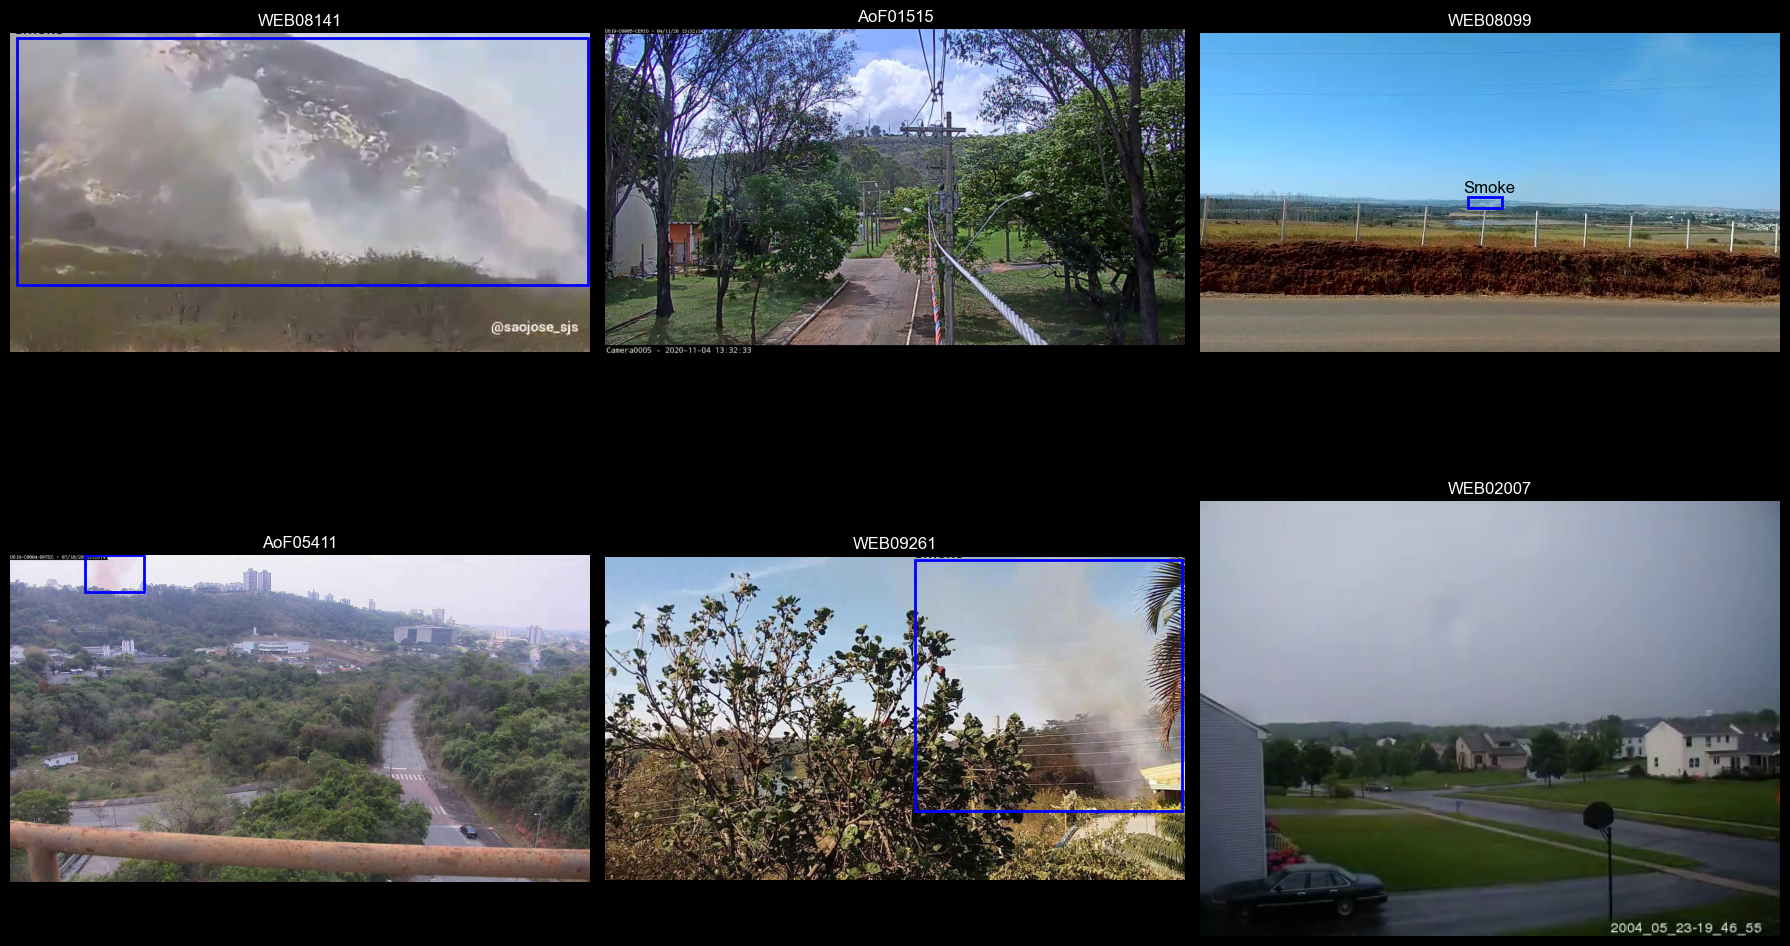

In [16]:
plot_random_samples(train=True, how_many=6)

Looking at the images we can see that, one good augmentation might be adding the fog effect, we can also see that the dataset consists of both small and big elements, this we will later divide into it's own categories for metrics

In [26]:
import os

import cv2
import torch
from albumentations import BboxParams
from matplotlib.transforms import Bbox
from torch.utils.data import Dataset
from torch import nn
import albumentations as A

from utils import yolo2yolo, yolo2matplotlib, yolo2torch, bbox_area
from extract_data import get_mappings
from torchmetrics import Metric
import copy


### Step2 - Dataset creation
This dataset class is made for RetinaNet and FasterRCNN, it enables adding transforms from albumentations, it uses `ModelHistory` class for tracking the metrics from torchmetrics library. 

In [27]:
class FireDatasetForDetection(Dataset):
    def __init__(self, train=True, transforms: list | None = None, bbox_params: A.BboxParams | None = None, target_resolution = (512, 512)):

        if bbox_params is None:
            bbox_params = A.BboxParams(format = 'yolo', label_fields=['labels'], min_visibility=0.2, clip=True, filter_invalid_bboxes=True)

        if transforms is None or any([not isinstance(transforms, A.BasicTransform) for transforms in transforms]):
            print("Transforms can be only from albumentations library")
            self.transforms = [A.NoOp()]
        else:
            self.transforms = transforms

        self.target_res = target_resolution
        self.transforms = A.Compose([A.LongestMaxSize(max_size=target_resolution[0]),
            A.PadIfNeeded(
                min_height=target_resolution[0],
                min_width=target_resolution[1],
                border_mode=cv2.BORDER_CONSTANT
            )] + self.transforms + [A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0), A.ToTensorV2()], bbox_params=bbox_params, seed=42)

        self.data = _gather_labels(train)
        self.imgs_path = DATA_DIR / "train" / "images" if train else DATA_DIR / "test" / "images"
        self.file_mappings = get_mappings(train)


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        datapoint_dict = self.data[idx]
        filename, labels, bboxes = datapoint_dict.values()
        image = cv2.imread(self.imgs_path / self.file_mappings[filename])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


        transform_dict = self.transforms(image=image, labels=labels, bboxes=bboxes)

        transformed_img = transform_dict["image"]
        transformed_labels = transform_dict["labels"]
        transformed_bboxes = transform_dict["bboxes"]


        transformed_bboxes = yolo2torch(transformed_bboxes, self.target_res)
        bboxes_areas = bbox_area(transformed_bboxes)
        transformed_labels = torch.tensor([label + 1 for label in transformed_labels], dtype=torch.int64)

        target = {
            "boxes": transformed_bboxes,
            "labels": transformed_labels,
            "image_id": torch.tensor([idx], dtype=torch.int64),
            "area": bboxes_areas,
            "iscrowd": torch.zeros(len(transformed_labels), dtype=torch.int64)
        }

        return transformed_img, target



class ModelHistory:
    """
    Simple class for tracking model's metrics, for each different evaluation add new step
    """

    def __init__(self, steps, name, *args):
        self.history = dict()
        self.name = name

        for step in steps:
            self.history[step] = {
               metric_name : [] for metric_name in args
            }

    def add_step_outcomes(self, step, **kwargs):
        for metric_name, metric_value in kwargs.items():
            if metric_name not in self.history[step]:
                self.history[step][metric_name] = []

            self.history[step][metric_name].append(metric_value)

    def return_targeted_metric_val(self, step: str, name: str):
        return self.history[step][name][-1]

    @classmethod
    def from_dict(cls, history_dict: dict, name: str):
        steps = list(history_dict.keys())
        instance = cls(steps, name)
        instance.history = copy.deepcopy(history_dict)

        return instance

### Step3 - Model training
These are the functions made for training the torchvision models, one difference from the previous project is that these model calculate the loss on their own, and do not any criterion, thus they do not produce the outputs - this data is only gathered during validation, additionally after the training, only the best model is saved

In [19]:
from functorch.dim import Tensor
from torch.utils.data import DataLoader
from torchmetrics import Metric
from tqdm import tqdm
import math
import torch
from utils import collate_fn, is_better_value
from torchmetrics.detection.mean_ap import  MeanAveragePrecision
from config import MODEL_DIR
from torchvision.models.detection.faster_rcnn import fasterrcnn_resnet50_fpn, FastRCNNPredictor
from torchvision.models.detection.retinanet import retinanet_resnet50_fpn_v2, RetinaNetHead


def _train_one_epoch(model, train_data, device, optimizer):
    model.train()
    pbar = tqdm(train_data)

    for images, targets in pbar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        losses = torch.stack(list(loss_dict.values())).sum()

        loss_value = losses.item()

        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping training")
            break

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()



def _val_one_epoch(model, val_data, device, history, metric: Metric):
    model.eval()
    pbar = tqdm(val_data)

    with torch.no_grad():
        for images, targets in pbar:
            images = list(image.to(device) for image in images)

            outputs = model(images)

            outputs = [{k: v.detach().cpu() for k, v in t.items()} for t in outputs]
            targets = [{k: v.cpu() for k, v in t.items()} for t in targets]
            metric.update(outputs, targets)

    outcomes = metric.compute()

    history.add_step_outcomes("val", **outcomes)



def train_model(model, batch_size, epochs, learning_rate, weight_decay, optimizer_class, device,
                metric = MeanAveragePrecision(), checkpoint_every: int = 5, target_metric = "map",
                target_res = (512, 512), num_workers = 0, model_name: str = ""):

    optimizer = optimizer_class(model.parameters(), lr=learning_rate, weight_decay=weight_decay, )

    dataset_train = FireDatasetForDetection(train=True, target_resolution=target_res)
    dataset_val = FireDatasetForDetection(train=False, target_resolution=target_res)

    train_data = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers = num_workers)
    val_data = DataLoader(dataset_val, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers = num_workers)

    history = ModelHistory(["train", "val"], model.__class__.__name__, metric)
    prev_metric_val = None

    for epoch in range(epochs):
        _train_one_epoch(model, train_data, device, optimizer)
        _val_one_epoch(model, val_data, device, history, metric)

        if epoch % checkpoint_every == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }
            torch.save(checkpoint, MODEL_DIR / f"model_{epoch}.pth")

        curr_metric_val = history.return_targeted_metric_val("val", target_metric)

        if prev_metric_val is None or \
        is_better_value(prev_metric_val, curr_metric_val, metric):

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }

            torch.save(checkpoint, MODEL_DIR / f"best_model_{model_name}.pth")

            prev_metric_val = curr_metric_val
            print(f"Found new best model at epoch {epoch} with metric {target_metric} and value {curr_metric_val}")

        metric.reset()

    return model, history

This is the function from previous project - it creates lineplots for each collected metric across the epochs

In [34]:
def plot_history(step_name: str, model_history: ModelHistory, metrics_used = None, max_img_per_width = 3):
    import math

    try:
        step_used = model_history.history[step_name]
        if metrics_used is None:
            metrics_used = step_used
        else:
            metrics_used = {metric_name: step_used[metric_name] for metric_name in metrics_used}
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        curr_ax.plot(metrics_used[metric])
        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()




These functions are from the previous project as well - the `plot_histories` function uses above function to create lineplots for each metric for each model

In [18]:
def _plot_step_for_models(names: list[str], data, ax: plt.Axes):
    import seaborn as sns
    for name, data in zip(names, data):
        sns.lineplot(x=range(len(data)), y=data, ax=ax, label=name)


def plot_histories(step_name: str, histories: list[ModelHistory], max_img_per_width = 3):
    import math
    try:
        metrics_used = histories[0].history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    models_names = [history.name for history in histories]

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        _plot_step_for_models(models_names, [history.history[step_name][metric] for history in histories], curr_ax)

        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()

These are some basic parameters used for training both fasterRCNN and Retinanet

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 3
batch_size = 16
epochs = 3
learning_rate = 0.001
weight_decay = 0.0005
tracked_metrics = ["map", "map_50", "map_small", "map_medium", "map_large", "mar_100"]

### FasterRCNN
This is a two stage model - the first module is the Region Proposal Network which return bboxes, where `something` is, then the next module takes the part of the image that is in the bbox and classifies it. This model is bigger and slower to train, but because it is a two stage model it should be better

In [ ]:

resnet_faster = fasterrcnn_resnet50_fpn(weights='DEFAULT', min_size = 256, max_size = 256)

in_features = resnet_faster.roi_heads.box_predictor.cls_score.in_features
resnet_faster.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

resnet_faster.to(device)

trained_faster, faster_history = train_model(
    model=resnet_faster,
    batch_size=batch_size,
    epochs=epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    optimizer_class=torch.optim.SGD,
    device=device,
    target_metric="map_50",
    checkpoint_every=5,
    target_res=(256, 256),
    num_workers=4,
    model_name="fasterRCNN"
)

print(faster_history.history)

In [ ]:
plot_history("val", faster_history, tracked_metrics)

### Retinanet
This model is a one stage model, this model does not cut out the part of the image and then tries to classify that but it immediately classifies every point on feature map, it is faster to train, but here more edits to this model were made, so it will need more epochs to learn

In [21]:
retina_model = retinanet_resnet50_fpn_v2(weights='DEFAULT', min_size=256, max_size=256)

num_classes = 3
in_channels = retina_model.backbone.out_channels
num_anchors = retina_model.head.classification_head.num_anchors

retina_model.head = RetinaNetHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

retina_model.to(device)

trained_retina, retina_history = train_model(
    model=retina_model,
    batch_size=batch_size,
    epochs=epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    optimizer_class=torch.optim.SGD,
    device=device,
    target_metric="map_50",
    checkpoint_every=5,
    target_res=(256, 256),
    num_workers=4,
    model_name="retina"
)

print(retina_history.history)

Transforms can be only from albumentations library
Transforms can be only from albumentations library


100%|██████████| 270/270 [01:29<00:00,  3.01it/s]


Found new best model at epoch 0 with metric map_50 and value 0.01323404349386692


100%|██████████| 270/270 [01:35<00:00,  2.82it/s]


Found new best model at epoch 1 with metric map_50 and value 0.022006450220942497


100%|██████████| 270/270 [01:19<00:00,  3.40it/s]


Found new best model at epoch 2 with metric map_50 and value 0.05590334162116051
{'train': {MeanAveragePrecision(): []}, 'val': {MeanAveragePrecision(): [], 'map': [tensor(0.0042), tensor(0.0058), tensor(0.0160)], 'map_50': [tensor(0.0132), tensor(0.0220), tensor(0.0559)], 'map_75': [tensor(0.0013), tensor(0.0021), tensor(0.0064)], 'map_small': [tensor(0.0044), tensor(0.0035), tensor(0.0051)], 'map_medium': [tensor(0.0044), tensor(0.0084), tensor(0.0158)], 'map_large': [tensor(7.0721e-05), tensor(0.0209), tensor(0.0390)], 'mar_1': [tensor(0.0095), tensor(0.0379), tensor(0.0562)], 'mar_10': [tensor(0.0245), tensor(0.0798), tensor(0.1188)], 'mar_100': [tensor(0.0411), tensor(0.1237), tensor(0.1894)], 'mar_small': [tensor(0.0625), tensor(0.0784), tensor(0.1285)], 'mar_medium': [tensor(0.0184), tensor(0.1825), tensor(0.2628)], 'mar_large': [tensor(5.6561e-05), tensor(0.1383), tensor(0.2744)], 'map_per_class': [tensor(-1.), tensor(-1.), tensor(-1.)], 'mar_100_per_class': [tensor(-1.), tenso

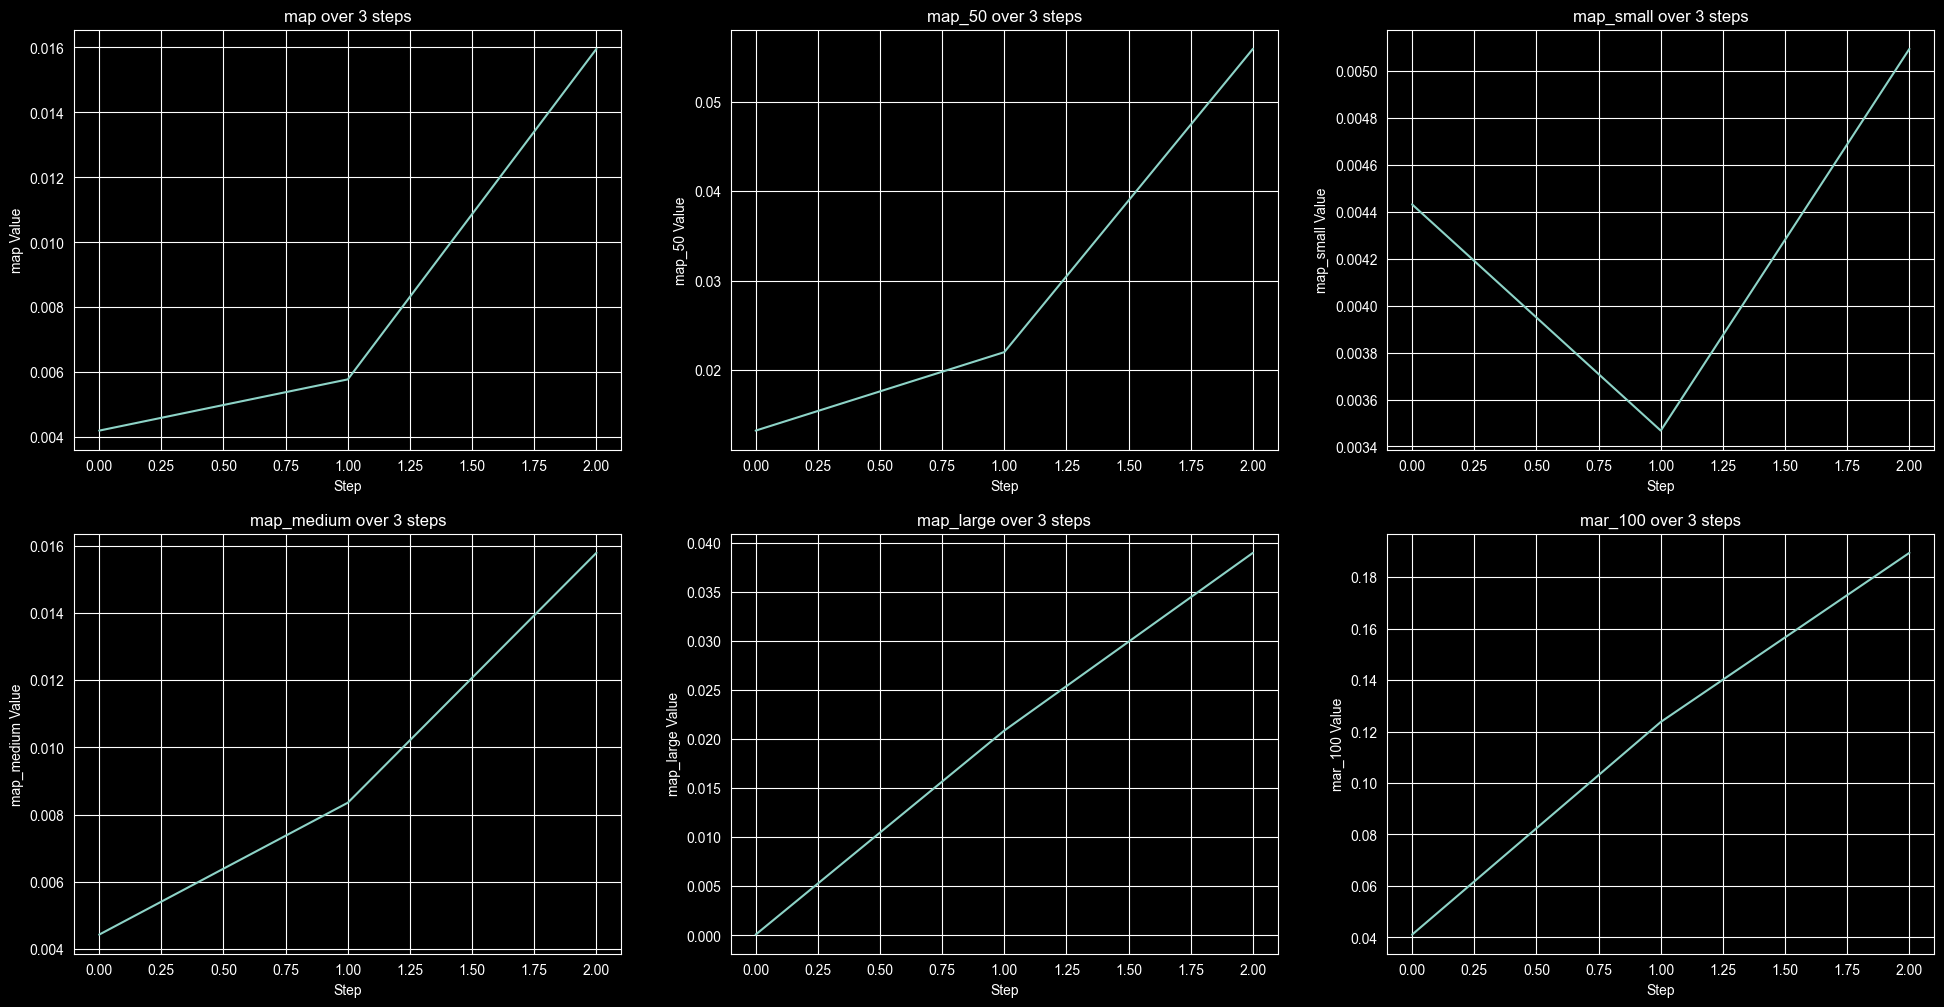

In [38]:
plot_history("val", retina_history, tracked_metrics)

### YOLO
This model is downloaded form ultralytics and it uses it's own set of augmentations, it randomly performs: grayscaling the image, using CLAHE method to use every possible pixel value, mosaic transformation, which combines 4 samples. It is another model which has only one stage. The version im using is `YOLO8` version n, which is the smallest available model. Even though this model excels at speed, the ultralytics team highly optimized it and so it could beat every model here. This model uses EarlyStopping with patience equal to 3, and cosine annealing for the learning rate adjustments.

In [23]:
from ultralytics import YOLO

def epoch_status(trainer):
    current_epoch = trainer.epoch
    current_map50 = trainer.metrics.get('metrics/mAP50(B)', 0.0)
    if hasattr(trainer, 'tloss'):
        train_loss = trainer.tloss.sum().item()
    else:
        train_loss = 0.0

    print(f"\n Epoch: {current_epoch} | Loss: {train_loss:.4f} | mAP50: {current_map50:.4f}")



In [31]:
yolo_model = YOLO("yolov8n.pt")
yolo_model.add_callback('on_fit_epoch_end', epoch_status)
results = yolo_model.train(data="fire.yaml", epochs = 2, batch = 16, patience = 3, save=True, save_period = 2, imgsz = 512,
            project = str(MODEL_DIR / "yolo") , name="test", workers = 4, cos_lr = True)


Ultralytics 8.4.37  Python-3.12.12 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=fire.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=test, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=3, 

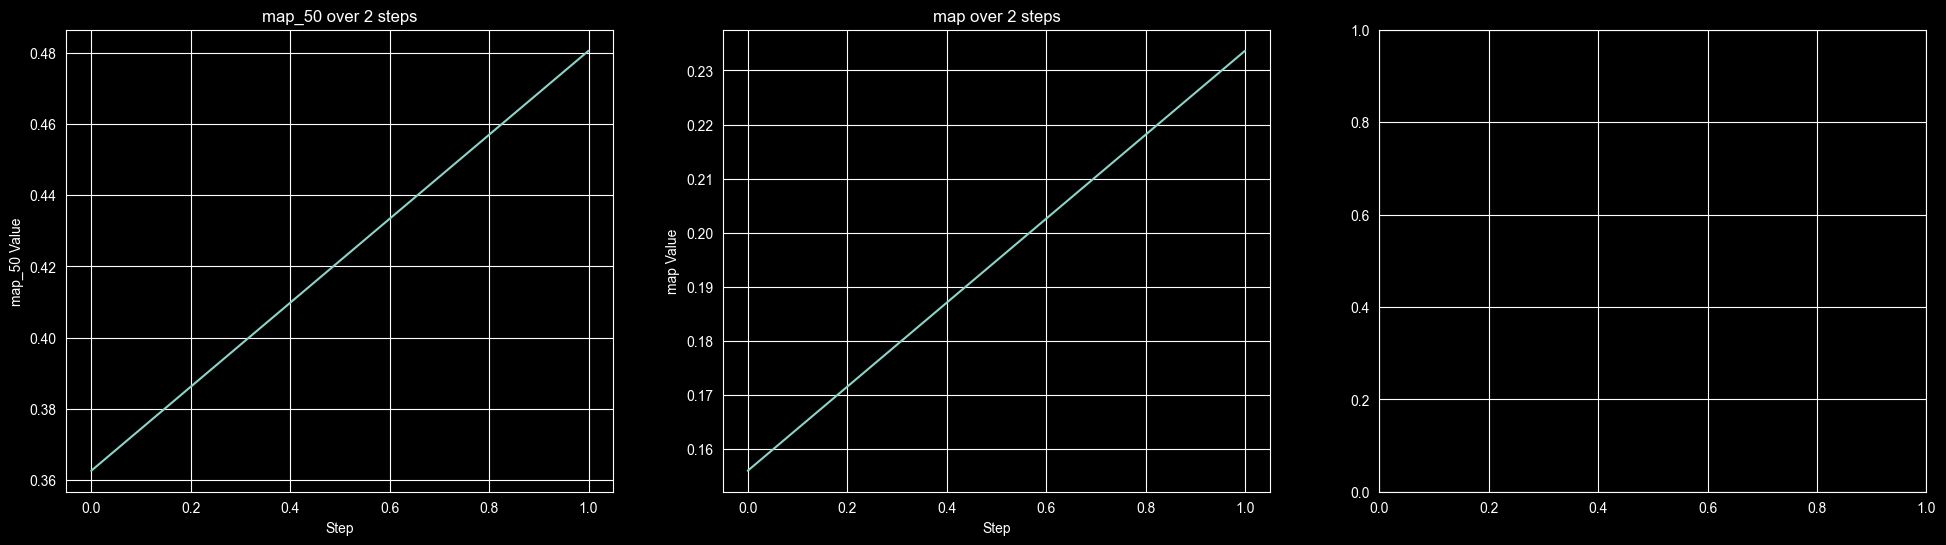

In [32]:
import pandas as pd

csv_path = DATA_DIR / "yolo" / "test" / "results.csv"

df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

yolo_history = {
    'val' : {
        'map_50': df['metrics/mAP50(B)'].tolist(),
        'map': df['metrics/mAP50-95(B)'].tolist(),
    }
}

yolo_history = ModelHistory.from_dict(yolo_history, "yolo")

plot_history("val", yolo_history)

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import FasterRCNNBoxScoreTarget

model = resnet_faster
model.to(device)
model.eval()

image_path = DATA_DIR / "test" / "images" / "AoF07765.jpg"
rgb_img = cv2.imread(image_path, 1)[:, :, ::-1]
rgb_img_float = np.float32(rgb_img) / 255

input_tensor = torch.tensor(rgb_img_float).permute(2, 0, 1).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)

pred_boxes = outputs[0]['boxes'].cpu().numpy()
pred_labels = outputs[0]['labels'].cpu().numpy()
pred_scores = outputs[0]['scores'].cpu().numpy()

if len(pred_boxes) == 0:
    print("Nothing to show here")
else:
    target_box = pred_boxes[0]
    target_class = pred_labels[0]

    target_layers = [model.backbone.body.layer4[-1]]

    targets = [FasterRCNNBoxScoreTarget(labels=[target_class], bounding_boxes=[target_box])]

    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor, targets)[0, :]

    cam_image = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)
